# Tensores, datasets y lotes con PyTorch

Retomaremos las matrices de Titanic y después examinaremos imágenes de CIFAR-10.
El objetivo es reconocer qué contiene una muestra, cómo se transforma y cómo se
agrupa con otras. Al final representaremos textos con un modelo preentrenado.
No entrenaremos un modelo.

## Contenido

1. Convertir arreglos NumPy a tensores.
2. Relacionar muestras y etiquetas con `Dataset` y `DataLoader`.
3. Cargar CIFAR-10 y transformar imágenes.
4. Interpretar las dimensiones de un lote y normalizar sus valores.
5. Guardar una selección para la sesión de visualización.
6. Representar textos con embeddings y buscar por similitud.

Abre esta notebook desde `sesion-03-pytorch`. La [preparación del proyecto](./README.md)
genera las salidas de Titanic y descarga CIFAR-10 antes de la clase.

In [1]:
from pathlib import Path

import numpy as np
import torch
from IPython.display import display
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2

project_dir = Path.cwd()
titanic_dir = project_dir.parent / "sesion-02-pandas" / "outputs"
if not (project_dir / "data_lab").is_dir():
    raise FileNotFoundError("Start this notebook from sesion-03-pytorch")
if not (titanic_dir / "features.npy").is_file():
    raise FileNotFoundError(
        "Run the session 2 main.py first to generate the Titanic arrays"
    )

## 1. Del arreglo al tensor

Un tensor de PyTorch organiza valores por dimensiones, igual que los arreglos
que ya conocemos. PyTorch añade herramientas para trabajar con aceleradores y
calcular derivadas durante el entrenamiento. Aquí nos interesa su representación
de datos: `shape`, `dtype` y `device`, el dispositivo donde residen los valores.

`torch.from_numpy` conserva el tipo del arreglo. Las variables de Titanic serán
`float32` y sus etiquetas `int64`. `dim` indica el eje de una operación, como
`axis` en NumPy. Los siguientes tensores se crean en CPU. `.numpy()` permite consultarlos
como arreglos y `.item()` extrae un número de un tensor de un solo elemento.

[Introducción oficial a los tensores](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html).

In [2]:
features_np = np.load(titanic_dir / "features.npy", allow_pickle=False)
labels_np = np.load(titanic_dir / "labels.npy", allow_pickle=False)
features = torch.from_numpy(features_np)
labels = torch.from_numpy(labels_np)
print("Features:", features.shape, features.dtype, features.device)
print("Labels:", labels.shape, labels.dtype)
print("Mean by feature:", features.mean(dim=0))
np.testing.assert_allclose(
    features.mean(dim=0).numpy(), features_np.mean(axis=0), rtol=1e-5
)
assert features.shape == (891, 4)
assert labels.shape == (891,)

Features: torch.Size([891, 4]) torch.float32 cpu
Labels: torch.Size([891]) torch.int64
Mean by feature: tensor([ 2.3086, 29.3616, 32.2042,  1.9046])


### Memoria compartida

`from_numpy` comparte memoria con el arreglo de origen. Si modificas uno,
cambia el otro. `.clone()` crea una copia del tensor. El experimento usa datos
pequeños para conservar intactas las variables de Titanic.

[`torch.from_numpy`](https://docs.pytorch.org/docs/stable/generated/torch.from_numpy.html).

In [3]:
values_np = np.array([10.0, 20.0], dtype=np.float32)
shared = torch.from_numpy(values_np)
independent = shared.clone()
shared[0] = 99
print("NumPy:", values_np)
print("Independent tensor:", independent)
assert independent[0].item() == 10.0

NumPy: [99. 20.]
Independent tensor: tensor([10., 20.])


### Ejercicio 1: una selección independiente

Crea una copia de las primeras tres filas de `features`, cambia su primera
posición y comprueba que `features` y `features_np` conservan sus valores.
Verifica la forma `(3, 4)`. Usa `.clone()` y las comprobaciones de NumPy que ya
conoces; puedes consultar un tensor de CPU con `.numpy()`.

In [4]:
original_rows = features[:3].clone()
independent_rows = features[:3].clone()
independent_rows[0, 0] = -999
assert independent_rows.shape == (3, 4)
torch.testing.assert_close(features[:3], original_rows)
np.testing.assert_array_equal(features_np[:3], original_rows.numpy())
print("Independent value:", independent_rows[0, 0].item())
print("Original value:", features[0, 0].item())

Independent value: -999.0
Original value: 3.0


## 2. Una muestra y un lote

Un `Dataset` permite obtener muestras. En los datasets indexables de esta sesión,
`len(dataset)` indica su cantidad y `dataset[i]` obtiene una muestra.
`TensorDataset` empareja la fila `i` de cada tensor: variables y etiqueta deben
pertenecer al mismo pasajero y tener la misma cantidad de filas.

[Datasets y DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html).

In [5]:
passenger_dataset = TensorDataset(features, labels)
passenger_features, passenger_label = passenger_dataset[0]
print("Samples:", len(passenger_dataset))
print("One sample:", passenger_features.shape, passenger_label.item())

Samples: 891
One sample: torch.Size([4]) 0


`DataLoader` agrupa muestras en lotes. `batch_size` fija cuántas incluir y
`shuffle=False` conserva el orden. `num_workers=0` carga en el mismo proceso.
`drop_last=False` conserva el último lote aunque sea más pequeño.

`Subset` permite trabajar con algunos índices. En este ejemplo, diez muestras
con lotes de cuatro producen tamaños 4, 4 y 2.

In [6]:
small_dataset = Subset(passenger_dataset, range(10))
loader = DataLoader(
    small_dataset, batch_size=4, shuffle=False, drop_last=False, num_workers=0
)
for batch_features, batch_labels in loader:
    print(batch_features.shape, batch_labels.shape)

torch.Size([4, 4]) torch.Size([4])
torch.Size([4, 4]) torch.Size([4])
torch.Size([2, 4]) torch.Size([2])


### Ejercicio 2: el último lote

Recorre `small_dataset` con `batch_size=3`. Anota los tamaños de los lotes y
cuántas muestras se procesan en total. Repite con `drop_last=True` y explica
qué muestra deja de entrar. Conserva `shuffle=False` en ambos recorridos.

In [7]:
keep_loader = DataLoader(
    small_dataset, batch_size=3, shuffle=False, drop_last=False, num_workers=0
)
keep_sizes = [len(batch_labels) for _, batch_labels in keep_loader]
drop_loader = DataLoader(
    small_dataset, batch_size=3, shuffle=False, drop_last=True, num_workers=0
)
drop_sizes = [len(batch_labels) for _, batch_labels in drop_loader]
assert keep_sizes == [3, 3, 3, 1]
assert drop_sizes == [3, 3, 3]
assert sum(keep_sizes) == 10
assert sum(drop_sizes) == 9
print("Keeping the last batch:", keep_sizes)
print("Dropping the last batch:", drop_sizes)
print("drop_last=True omits sample 10, the final passenger in this subset.")

Keeping the last batch: [3, 3, 3, 1]
Dropping the last batch: [3, 3, 3]
drop_last=True omits sample 10, the final passenger in this subset.


### Mezclar el orden de forma repetible

`shuffle=True` cambia el orden, manteniendo juntos los componentes de cada
muestra. Un `torch.Generator` con semilla permite repetir ese orden en el mismo
entorno. Creamos un generador nuevo para cada recorrido: reutilizar uno avanza
su estado y puede dar otro orden.

`torch.arange(10)` crea los índices de 0 a 9. `next(iter(loader))` obtiene
un lote; el `[0]` extrae su único componente porque este dataset tiene un solo
tensor. Mostramos índices pequeños para que el efecto se vea. La semilla no garantiza
resultados idénticos entre todas las versiones y plataformas.

[Reproducibilidad](https://docs.pytorch.org/docs/stable/notes/randomness.html).

In [8]:
sample_ids = TensorDataset(torch.arange(10))
orders = []
for _ in range(2):
    generator = torch.Generator().manual_seed(42)
    shuffled_loader = DataLoader(
        sample_ids, batch_size=10, shuffle=True, generator=generator, num_workers=0
    )
    ids = next(iter(shuffled_loader))[0]
    orders.append(ids.tolist())
print(orders)
assert orders[0] == orders[1]

[[6, 5, 4, 0, 8, 9, 2, 1, 3, 7], [6, 5, 4, 0, 8, 9, 2, 1, 3, 7]]


## 3. CIFAR-10: imágenes y clases

CIFAR-10 contiene imágenes RGB de 32 × 32 píxeles en diez clases. Tiene 50 000
imágenes de entrenamiento y 10 000 de prueba. Usaremos el conjunto de prueba
(`train=False`) para inspección, sin evaluar ni entrenar modelos.

`root` indica la carpeta local y `download=False` reutiliza la descarga preparada.
Sin transformación, cada muestra devuelve una imagen de Pillow y el identificador
entero de su clase. `classes` relaciona esos identificadores con sus nombres.
Ampliamos la imagen solo para verla en pantalla.

[Fuente de CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) ·
[API de CIFAR10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

Samples: 10000
Image size: (32, 32) Mode: RGB
Class: 3 cat


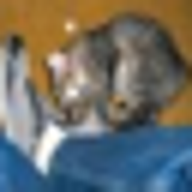

In [9]:
raw_dataset = CIFAR10(root=project_dir / "data", train=False, download=False)
raw_image, class_id = raw_dataset[0]
print("Samples:", len(raw_dataset))
print("Image size:", raw_image.size, "Mode:", raw_image.mode)
print("Class:", class_id, raw_dataset.classes[class_id])
display(raw_image.resize((192, 192)))

### Transformar una imagen

La imagen como arreglo tiene orden `(alto, ancho, canales)`. PyTorch suele
trabajar con `(canales, alto, ancho)`. `v2.ToImage()` cambia la representación a
un tensor de imagen y `v2.ToDtype(torch.float32, scale=True)` convierte los
enteros entre 0 y 255 a flotantes entre 0 y 1. `v2.Compose` aplica los pasos en
orden. Cambiar solo el tipo no equivale a cambiar la escala.

[Transformaciones de torchvision](https://docs.pytorch.org/vision/stable/transforms.html).

In [10]:
image_array = np.array(raw_image)
image_uint8 = v2.ToImage()(raw_image)
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
image = transform(raw_image)
print("Array:", image_array.shape, image_array.dtype)
print("Image tensor:", image_uint8.shape, image_uint8.dtype)
print("Scaled tensor:", image.shape, image.dtype)
print("Value range:", image.min().item(), image.max().item())
assert image.shape == (3, 32, 32)

Array:

 (32, 32, 3) uint8
Image tensor: torch.Size([3, 32, 32]) torch.uint8
Scaled tensor: torch.Size([3, 32, 32]) torch.float32
Value range: 0.05098039656877518 1.0


### Leer imágenes bajo demanda

`DataLoader` organiza lotes, pero no determina cómo se almacenan las muestras.
`CIFAR10` carga su arreglo de imágenes en RAM al construirlo. Para mostrar otra estrategia,
guardaremos **32 imágenes del mismo dataset** como archivos PNG y crearemos un `Dataset` propio.
Esta preparación usa la instancia ya cargada; no convierte la descarga original en una lectura por streaming.


In [11]:
image_dir = project_dir / "outputs" / "lazy_images"
image_dir.mkdir(parents=True, exist_ok=True)
image_samples = []
for index in range(32):
    sample_image, sample_label = raw_dataset[index]
    image_path = image_dir / f"image_{index:03}.png"
    sample_image.save(image_path)
    image_samples.append((image_path, sample_label))
print("Saved images:", len(image_samples))

Saved images: 32


El nuevo dataset conserva **rutas y etiquetas**, sin abrir las imágenes en `__init__`.
`__getitem__` abre únicamente el archivo solicitado, aplica la transformación y cierra el archivo con `with`.
Python llama ese método al escribir `dataset[index]`; `__len__` permite consultar su tamaño.
El contador `read_count` hará visible cuándo se leen archivos.


In [12]:
from PIL import Image
from torch.utils.data import Dataset


class DiskImageDataset(Dataset):
    def __init__(self, samples: list[tuple[Path, int]], transform: v2.Compose):
        self.samples = samples
        self.transform = transform
        self.read_count = 0

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        image_path, label = self.samples[index]
        with Image.open(image_path) as image_file:
            image = self.transform(image_file.convert("RGB"))
        self.read_count += 1
        return image, label


disk_dataset = DiskImageDataset(image_samples, transform)
print("Reads after construction:", disk_dataset.read_count)
disk_image, disk_label = disk_dataset[0]
print("Reads after one sample:", disk_dataset.read_count)
print("Sample:", disk_image.shape, disk_label)

Reads after construction: 0
Reads after one sample: 1
Sample: torch.Size([3, 32, 32]) 3


In [13]:
disk_loader = DataLoader(disk_dataset, batch_size=8, shuffle=False, num_workers=0)
disk_images, disk_labels = next(iter(disk_loader))
print("Batch:", disk_images.shape, disk_labels.shape)
print("Reads after one batch:", disk_dataset.read_count)

sample_count = 0
for _batch_images, batch_labels in disk_loader:
    sample_count += len(batch_labels)
print("Processed samples:", sample_count)

Batch: torch.Size([8, 3, 32, 32]) torch.Size([8])
Reads after one batch: 9
Processed samples: 32


El contador pasa de **0 a 1 y después a 9**: construir el dataset no abre imágenes;
consultar una muestra abre una; solicitar un lote abre otras ocho.
Recorrer `disk_loader` de nuevo empieza desde el principio y vuelve a leer los archivos.

Con `num_workers=0`, procesamos un lote a la vez. No guardamos los lotes en una lista ni
los concatenamos: así podemos recorrer una colección de imágenes que no cabría completa en RAM.
Las rutas y etiquetas sí permanecen en memoria. Varios workers pueden preparar lotes por adelantado
y aumentar el consumo; no los necesitamos para esta demostración.
La notebook conserva además las instancias originales de CIFAR-10 para los ejemplos anteriores.

[Dataset personalizado: tutorial oficial](https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html).


## 4. Dimensiones de un lote de imágenes

Pasamos la transformación a `CIFAR10`: se aplica cuando pedimos cada muestra.
El `DataLoader` añade un eje inicial para las imágenes del lote:
`(N, C, H, W)` corresponde a cantidad de imágenes, canales, alto y ancho.
Las etiquetas quedan en un vector `(N,)`.

`next(iter(loader))` obtiene el primer lote. Reducir `dim=(2, 3)` promedia alto
y ancho y conserva una media por canal para cada imagen.

In [14]:
cifar = CIFAR10(
    root=project_dir / "data", train=False, download=False, transform=transform
)
image_loader = DataLoader(cifar, batch_size=16, shuffle=False, num_workers=0)
images, image_labels = next(iter(image_loader))
print("Images:", images.shape)
print("Labels:", image_labels.shape, image_labels.dtype)
print("First class:", cifar.classes[image_labels[0].item()])
image_channel_means = images.mean(dim=(2, 3))
print("Mean per image and channel:", image_channel_means.shape)
assert images.shape == (16, 3, 32, 32)

Images: torch.Size([16, 3, 32, 32])
Labels: torch.Size([16]) torch.int64
First class: cat
Mean per image and channel: torch.Size([16, 3])


### Ejercicio 3: una media por canal

Calcula una sola media por canal para las 16 imágenes del lote. El resultado
debe tener forma `(3,)`. Puedes promediar `image_channel_means` sobre las
imágenes o reducir directamente los ejes necesarios de `images`. Compara ambos
cálculos con `torch.testing.assert_close`, que comprueba cercanía numérica como
`assert_allclose` en NumPy. Explica qué ejes desaparecen.

In [15]:
channel_means_from_images = image_channel_means.mean(dim=0)
channel_means_direct = images.mean(dim=(0, 2, 3))
assert channel_means_direct.shape == (3,)
torch.testing.assert_close(channel_means_direct, channel_means_from_images)
print("Batch mean by channel:", channel_means_direct)
print("The batch, height and width axes disappear; only the channel axis remains.")

Batch mean by channel: tensor([0.4794, 0.4697, 0.4463])
The batch, height and width axes disappear; only the channel axis remains.


### Normalizar valores

`Normalize` aplica `(valor - mean) / std` a cada canal. Con `mean=0.5` y
`std=0.5` para los tres canales, el intervalo `[0, 1]` pasa a `[-1, 1]`.
Son constantes elegidas para este ejemplo: no son estadísticas calculadas de
CIFAR-10 y no garantizan que el lote tenga media cero y desviación uno.

La operación devuelve un tensor nuevo con la misma forma. Guardaremos para la
siguiente sesión las imágenes en `[0, 1]`, que son más directas de visualizar.

[`Normalize`](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.Normalize.html).

In [16]:
normalize = v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
normalized_images = normalize(images)
print("Original range:", images.min().item(), images.max().item())
print(
    "Normalized range:", normalized_images.min().item(), normalized_images.max().item()
)
assert normalized_images.shape == images.shape

Original range: 0.0 1.0
Normalized range: -1.0 1.0


### Ejercicio 4: recuperar la escala

Invierte la transformación anterior para recuperar valores en `[0, 1]`.
Guarda el resultado en `restored_images` y compáralo con `images` mediante
`torch.testing.assert_close`. Explica por qué conservar la forma del tensor
no significa conservar sus valores.

In [17]:
restored_images = normalized_images * 0.5 + 0.5
torch.testing.assert_close(restored_images, images)
print("Restored range:", restored_images.min().item(), restored_images.max().item())
print(
    "Shape only records the number of values along each axis; normalization changed those values without changing the axes."
)

Restored range: 0.0 1.0
Shape only records the number of values along each axis; normalization changed those values without changing the axes.


## 5. Reutilizar y guardar los datos

La función `collect_samples` del módulo usa `Subset` y `DataLoader` para recorrer
las primeras muestras. Une los lotes con `torch.cat(..., dim=0)`: concatena sobre
un eje existente. En el ejemplo siguiente, dos grupos de dos imágenes recuperan
un tensor de cuatro imágenes.

La concatenación es adecuada para esta selección pequeña. Para un dataset muy grande,
procesa o guarda cada lote por separado; reunirlos todos volvería a llenar la memoria.


In [18]:
first_part = images[:2]
second_part = images[2:4]
joined = torch.cat([first_part, second_part], dim=0)
print(joined.shape)
torch.testing.assert_close(joined, images[:4])

torch.Size([4, 3, 32, 32])


Para contar clases, `torch.bincount` cuenta cuántas veces aparece cada
identificador. `minlength=10` incluye las diez clases aunque alguna no aparezca
en la selección. El módulo añade sus nombres para escribir el CSV.

Estos conteos describen las primeras 64 imágenes, no el conjunto completo.

In [19]:
from data_lab.inspection import collect_samples, image_transform, label_summary

torch.testing.assert_close(image_transform()(raw_image), image)
selected_images, selected_labels = collect_samples(cifar, limit=64, batch_size=16)
counts = torch.bincount(selected_labels, minlength=len(cifar.classes))
print("Selected images:", selected_images.shape)
print("Counts:", counts.tolist())
print(label_summary(selected_labels, cifar.classes))
assert counts.sum().item() == 64

Selected images: torch.Size([64, 3, 32, 32])
Counts: [6, 3, 2, 6, 6, 7, 11, 7, 7, 9]
[{'class_id': 0, 'class_name': 'airplane', 'count': 6, 'proportion': 0.09375}, {'class_id': 1, 'class_name': 'automobile', 'count': 3, 'proportion': 0.046875}, {'class_id': 2, 'class_name': 'bird', 'count': 2, 'proportion': 0.03125}, {'class_id': 3, 'class_name': 'cat', 'count': 6, 'proportion': 0.09375}, {'class_id': 4, 'class_name': 'deer', 'count': 6, 'proportion': 0.09375}, {'class_id': 5, 'class_name': 'dog', 'count': 7, 'proportion': 0.109375}, {'class_id': 6, 'class_name': 'frog', 'count': 11, 'proportion': 0.171875}, {'class_id': 7, 'class_name': 'horse', 'count': 7, 'proportion': 0.109375}, {'class_id': 8, 'class_name': 'ship', 'count': 7, 'proportion': 0.109375}, {'class_id': 9, 'class_name': 'truck', 'count': 9, 'proportion': 0.140625}]


Desde la terminal, ejecuta:

```bash
uv run --locked python main.py
```

La aplicación guarda `images.npy`, `labels.npy`, `class_counts.csv` y
`report.json` en `outputs/`. El reporte describe la selección, el orden de ejes
y los nombres de clases. `--limit` y `--batch-size` permiten cambiar la cantidad
de muestras y el tamaño de lote. Por ejemplo, `--limit 10 --batch-size 4`
conserva también las dos muestras del último lote.

Continúa con el [ejercicio 5](./PRACTICA.md), que amplía el resumen por clase.
Antes de entregar, reinicia el kernel y ejecuta todas las celdas.

## 6. Embeddings: representar y buscar textos

Un **embedding** es un vector numérico producido por un modelo. Permite comparar
textos mediante operaciones con tensores. Sus componentes se aprenden: no debemos
interpretar cada columna como una característica con nombre, como en Titanic.

**Sentence Transformers** es una biblioteca que utiliza modelos preentrenados para
obtener estos vectores. Usaremos `all-MiniLM-L6-v2`: transforma cada texto en
384 números. El modelo trabaja en inglés y trunca entradas largas a 256 tokens
(fragmentos de palabras). Aquí usamos textos cortos y CPU.

La primera carga descarga los pesos; las siguientes usan la caché local.
[Ficha del modelo](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2).

### El mismo ejemplo en GPU

Abre la [demo de embeddings en Colab: CPU y CUDA](https://colab.research.google.com/drive/18C8kn_iWqNVayn9ZvcrX203rL4pKpPky).
Repite la búsqueda con `device="cuda"` y compara el tiempo de procesar 500 textos en CPU y GPU.
Selecciona GPU en **Entorno de ejecución → Cambiar tipo de entorno de ejecución**.
Es una demostración complementaria, sin ejercicios adicionales.


In [20]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")

texts = [
    "The package arrived two weeks late.",
    "Delivery was delayed and the box was damaged.",
    "The coffee tastes fresh and delicious.",
    "Customer support answered my question quickly.",
    "The book contains useful Python examples.",
]
text_vectors = text_model.encode(texts, batch_size=2, convert_to_tensor=True)
print("Shape:", text_vectors.shape)
print("Type:", text_vectors.dtype)
print("Device:", text_vectors.device)
print("First vector, first values:", text_vectors[0, :5])

C:\Users\MOISES INFORMATICA\.codex\worktrees\a92c\ia-programacion-uady-main\unidades\02-datos-y-representaciones\tareas\sesion-03-pytorch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\MOISES INFORMATICA\.codex\worktrees\a92c\ia-programacion-uady-main\unidades\02-datos-y-representaciones\tareas\sesion-03-pytorch\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MOISES INFORMATICA\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-developmen

C:\Users\MOISES INFORMATICA\.codex\worktrees\a92c\ia-programacion-uady-main\unidades\02-datos-y-representaciones\tareas\sesion-03-pytorch\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MOISES INFORMATICA\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4542.68it/s]

Shape: torch.Size([5, 384])
Type: torch.float32
Device: cpu
First vector, first values: tensor([-0.0211,  0.0145,  0.0284,  0.0555,  0.0630])


### Una fila por texto

El resultado tiene forma `(5, 384)`: cinco textos y 384 componentes por texto.
`convert_to_tensor=True` devuelve un tensor PyTorch; `batch_size=2` procesa los
textos en lotes de hasta dos, conservando el orden de las filas. No cambia cuántos
vectores se producen. `text_vectors[i]` corresponde a `texts[i]`.

Podemos encapsular esa operación en una función. Reutilizamos el modelo cargado
para no volver a cargarlo en cada llamada. La consulta también se convierte con
**el mismo modelo**; dimensiones iguales por sí solas no garantizan que dos
modelos produzcan vectores comparables.


In [21]:
def encode_texts(texts: list[str], batch_size: int = 32) -> torch.Tensor:
    return text_model.encode(texts, batch_size=batch_size, convert_to_tensor=True)


query = "My delivery arrived late."
query_vectors = encode_texts([query])
print("Query shape:", query_vectors.shape)

Query shape: torch.Size([1, 384])


### Comparar direcciones: similitud coseno

Para comparar la dirección de los vectores, los normalizamos a longitud uno.
`dim=1` indica que se normaliza cada **fila**. Esta operación es distinta de
reescalar los canales de imagen con media y desviación estándar.

Después, `@` calcula el producto matricial. Multiplicar `(5, 384)` por `(384,)`
produce cinco puntuaciones: una por texto. Con vectores de longitud uno, ese
producto equivale a la similitud coseno. Un valor mayor indica mayor cercanía
según el modelo; no es una probabilidad ni demuestra que una afirmación sea cierta.


In [22]:
import torch.nn.functional as F

normalized_texts = F.normalize(text_vectors, p=2, dim=1)
normalized_query = F.normalize(query_vectors, p=2, dim=1)
scores = normalized_texts @ normalized_query[0]
print("Vector lengths:", torch.linalg.vector_norm(normalized_texts, dim=1))
print("Scores shape:", scores.shape)
for text, score in zip(texts, scores, strict=True):
    print(f"{score.item():.3f} | {text}")

Vector lengths: tensor([1., 1., 1., 1., 1.])
Scores shape: torch.Size([5])
0.692 | The package arrived two weeks late.
0.588 | Delivery was delayed and the box was damaged.
0.092 | The coffee tastes fresh and delicious.
0.270 | Customer support answered my question quickly.
-0.016 | The book contains useful Python examples.


### Recuperar los resultados con `topk`

`torch.topk` devuelve las puntuaciones más altas y sus posiciones en el tensor.
Esas posiciones permiten recuperar los textos originales. Pedimos dos resultados;
`k` no debe superar la cantidad de textos disponibles.

La búsqueda puede recuperar opiniones opuestas sobre un mismo tema. Además,
`topk` siempre devuelve la cantidad solicitada, aunque ninguna coincidencia sea
relevante. Revisamos el texto recuperado junto con su puntuación.


In [23]:
best_scores, best_indices = torch.topk(scores, k=2)
for score, index in zip(best_scores, best_indices, strict=True):
    text_index = int(index.item())
    print(f"{score.item():.3f} | {texts[text_index]}")

# Check that the matrix operation agrees with cosine similarity.
expected_scores = F.cosine_similarity(text_vectors, query_vectors, dim=1)
torch.testing.assert_close(scores, expected_scores)

0.692 | The package arrived two weeks late.
0.588 | Delivery was delayed and the box was damaged.


Aquí usamos un modelo para representar textos y después operaciones de PyTorch
para buscar. En una colección mayor, los vectores de los textos se calculan una
vez y se reutilizan; cada nueva consulta requiere solamente su propio vector.

[Similitud textual en Sentence Transformers](https://www.sbert.net/docs/sentence_transformer/usage/semantic_textual_similarity.html)
· [Normalización por dimensión](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html)
· [Selección con topk](https://docs.pytorch.org/docs/stable/generated/torch.topk.html).
